In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas
import geodatasets
import folium


In [2]:
df1 = pd.read_csv('volcano_data_2010.csv')

In [3]:
df = df1.loc[:, ("Year", "Name", "Country", "Latitude", "Longitude", "Type")]
df.head()

,Year,Name,Country,Latitude,Longitude,Type
0,2010,Tungurahua,Ecuador,-1.467,-78.442,Stratovolcano
1,2010,Eyjafjallajokull,Iceland,63.630,-19.620,Stratovolcano
2,2010,Pacaya,Guatemala,14.381,-90.601,Complex volcano
3,2010,Sarigan,United States,16.708,145.780,Stratovolcano
4,2010,Karangetang [Api Siau],Indonesia,2.780,125.480,Stratovolcano


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Year       63 non-null     int64  
 1   Name       63 non-null     str    
 2   Country    63 non-null     str    
 3   Latitude   63 non-null     float64
 4   Longitude  63 non-null     float64
 5   Type       63 non-null     str    
dtypes: float64(2), int64(1), str(3)
memory usage: 3.1 KB


In [5]:
geometry = geopandas.points_from_xy(df.Longitude, df.Latitude)
geo_df = geopandas.GeoDataFrame(
    df[["Year", "Name", "Country", "Latitude", "Longitude", "Type"]], geometry=geometry
)

geo_df.head()

,Year,Name,Country,Latitude,Longitude,Type,geometry
0,2010,Tungurahua,Ecuador,-1.467,-78.442,Stratovolcano,POINT (-78.442 -1.467)
1,2010,Eyjafjallajokull,Iceland,63.630,-19.620,Stratovolcano,POINT (-19.62 63.63)
2,2010,Pacaya,Guatemala,14.381,-90.601,Complex volcano,POINT (-90.601 14.381)
3,2010,Sarigan,United States,16.708,145.780,Stratovolcano,POINT (145.78 16.708)
4,2010,Karangetang [Api Siau],Indonesia,2.780,125.480,Stratovolcano,POINT (125.48 2.78)


In [6]:
type(geo_df)

geopandas.geodataframe.GeoDataFrame

In [7]:
type(df)

pandas.DataFrame

In [8]:
world = geopandas.read_file(geodatasets.get_path("naturalearth.land"))

In [9]:
df.Type.unique()

<StringArray>
[     'Stratovolcano',    'Complex volcano',     'Shield volcano',
 'Subglacial volcano',          'Lava dome',            'Caldera']
Length: 6, dtype: str

Text(0.5, 1.0, 'Volcanoes')

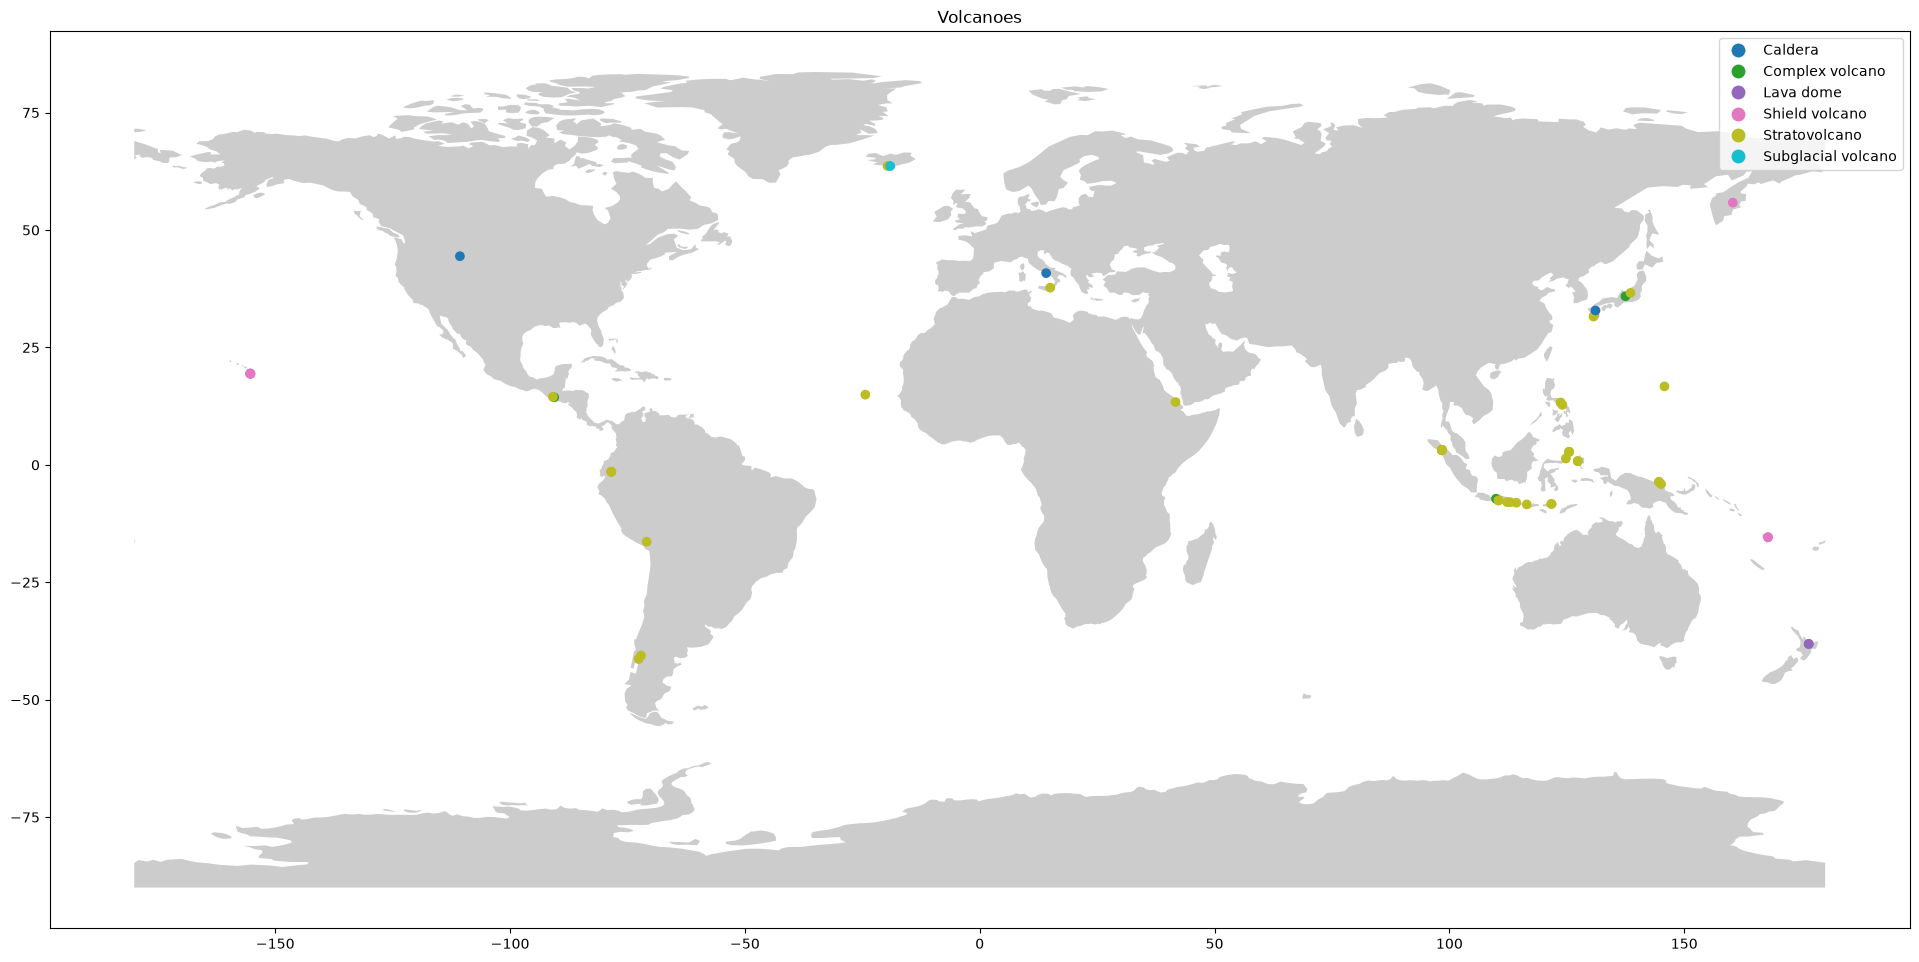

In [10]:
fig, ax = plt.subplots(figsize=(24, 18))
world.plot(ax=ax, alpha=0.4, color="grey")
geo_df.plot(column="Type", ax=ax, legend=True)
plt.title("Volcanoes")

##1. OpenStreetMap

In [11]:
#Folium OpenStreetMap
map = folium.Map(location=[28.474, 77.503], tiles="OpenStreetMap", zoom_start=13)
map

##2. Add Markers

In [12]:
# Create a geometry list from the GeoDataFrame
geo_df_list = [[point.xy[1][0], point.xy[0][0]] for point in geo_df.geometry]

# Iterate through list and add a marker for each volcano, color-coded by its type.
i = 0
for coordinates in geo_df_list:
    # assign a color marker for the type of volcano, Strato being the most common
    if geo_df.Type[i] == "Stratovolcano":
        type_color = "green"
    elif geo_df.Type[i] == "Complex volcano":
        type_color = "blue"
    elif geo_df.Type[i] == "Shield volcano":
        type_color = "orange"
    elif geo_df.Type[i] == "Lava dome":
        type_color = "pink"
    else:
        type_color = "purple"

    # Place the markers with the popup labels and data
    map.add_child(
        folium.Marker(
            location=coordinates,
            popup="Year: "
            + str(geo_df.Year[i])
            + "<br>"
            + "Name: "
            + str(geo_df.Name[i])
            + "<br>"
            + "Country: "
            + str(geo_df.Country[i])
            + "<br>"
            + "Type: "
            + str(geo_df.Type[i])
            + "<br>"
            + "Coordinates: "
            + str(geo_df_list[i]),
            icon=folium.Icon(color="%s" % type_color),
        )
    )
    i = i + 1

In [13]:
map

##3. Heatmaps

In [14]:
from folium import plugins

map = folium.Map(location=[15, 30], tiles="Cartodb dark_matter", zoom_start=2)

heat_data = [[point.xy[1][0], point.xy[0][0]] for point in geo_df.geometry]

heat_data
plugins.HeatMap(heat_data).add_to(map)

map

/home/ashrma0502/ayush/Intro to Machine Learning/venv/lib/python3.14/site-packages/folium/raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore
